<a href="https://colab.research.google.com/github/KhagendraN/DataAnalysis/blob/main/Bias_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Bias **Dataset**

 # Comprehensive Analysis of Bias Dataset
This notebook provides an exploratory data analysis (EDA) of the `bias_dataset.csv` file, which contains Nepali sentences labeled with multiple bias categories.


In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting style
plt.style.use('ggplot')
sns.set_palette('deep')

# Load data

In [21]:
file_path = "/content/bias_dataset.csv"
df = pd.read_csv(filepath_or_buffer=file_path)

print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 540 entries, 0 to 539
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   sentence       540 non-null    object
 1   primary_bias   540 non-null    object
 2   all_labels     540 non-null    object
 3   gender         540 non-null    int64 
 4   caste          540 non-null    int64 
 5   religion       540 non-null    int64 
 6   region         540 non-null    int64 
 7   appearance     540 non-null    int64 
 8   socioeconomic  540 non-null    int64 
 9   age            540 non-null    int64 
 10  disability     540 non-null    int64 
 11  political      540 non-null    int64 
dtypes: int64(9), object(3)
memory usage: 50.8+ KB
None


In [22]:
df = df.drop("primary_bias", axis=1)
df = df.drop("all_labels", axis=1)
df.sample(n=10)

,sentence,gender,caste,religion,region,appearance,socioeconomic,age,disability,political
503,नेविसंघको ढोंगी र नाटकीय आन्दोलनले फेरि जनतालाई हसाउँदैछ।,0,0,0,0,0,0,0,0,1
243,काठमाडौंका राजनीतिज्ञहरूले देश बिगारे।,0,0,0,1,0,0,0,0,0
312,गरिब तथा निम्न वर्गका मधेसी शिक्षकहरू राजनीतिक फोरममा लागेका छन्।,0,0,0,1,0,1,1,0,0
70,"यादव, चौधरी, मण्डल जस्ता जातिका व्यक्तिहरू स्थानीय गाउँ परिषदमा सक्रिय छन्।",0,1,0,0,0,0,0,0,0
500,प्रचण्डले युवा नेताहरूलाई अवसर दिएनन्।,0,0,0,0,0,0,1,0,1
50,मधेसका महिलाहरूले राजनीति गर्नुहुँदैन।,1,0,0,1,0,0,0,0,0
294,उच्च वर्गका मानिसहरू देशको विकास गर्छन्।,0,0,0,0,0,1,0,0,0
449,प्रहरीले गरेको गोली प्रहार राष्ट्रिय एकताको रक्षा गर्न आवश्यक थियो।,0,0,0,0,0,0,0,0,1
258,सुन्दर केटीहरूले मात्र राम्रो जागिर पाउँछन्।,1,0,0,0,1,0,0,0,0
98,दलित विद्यार्थीहरूले राम्रो पढ्न सक्दैनन्।,0,1,0,0,0,0,0,0,0


# Label Distribution

/tmp/ipykernel_6927/1566676883.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=label_counts.values, y=label_counts.index, palette='viridis')


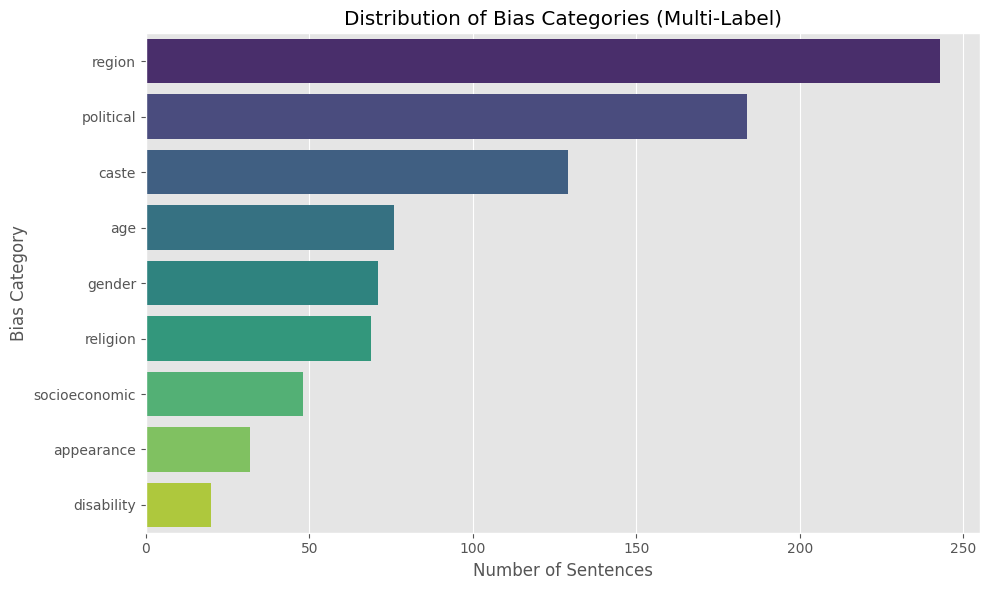

Label Counts:
region           243
political        184
caste            129
age               76
gender            71
religion          69
socioeconomic     48
appearance        32
disability        20
dtype: int64


In [23]:
# List of all bias categories
categories = ['gender', 'caste', 'religion', 'region', 'appearance',
             'socioeconomic', 'age', 'disability', 'political']

# Calculate sums
label_counts = df[categories].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=label_counts.values, y=label_counts.index, palette='viridis')
plt.title('Distribution of Bias Categories (Multi-Label)')
plt.xlabel('Number of Sentences')
plt.ylabel('Bias Category')
plt.tight_layout()
plt.show()

print("Label Counts:")
print(label_counts)

# Multi-Label Analysis

/tmp/ipykernel_6927/3579269047.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=num_labels_dist.index, y=num_labels_dist.values, palette='mako')


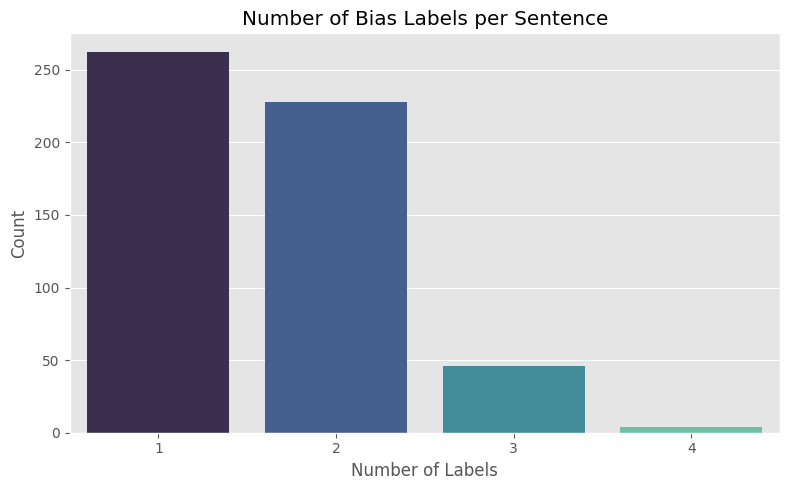

Sentences with no labels: 0
Sentences with exactly 1 label: 262
Sentences with >1 labels (Multi-label): 278


In [24]:
# Calculate number of labels per sentence
df['num_labels'] = df[categories].sum(axis=1)

# Count distribution
num_labels_dist = df['num_labels'].value_counts().sort_index()

plt.figure(figsize=(8, 5))
sns.barplot(x=num_labels_dist.index, y=num_labels_dist.values, palette='mako')
plt.title('Number of Bias Labels per Sentence')
plt.xlabel('Number of Labels')
plt.ylabel('Count')
plt.xticks(np.arange(len(num_labels_dist)))
plt.tight_layout()
plt.show()

print(f"Sentences with no labels: {len(df[df['num_labels'] == 0])}")
print(f"Sentences with exactly 1 label: {len(df[df['num_labels'] == 1])}")
print(f"Sentences with >1 labels (Multi-label): {len(df[df['num_labels'] > 1])}")


# Label Co-occurence

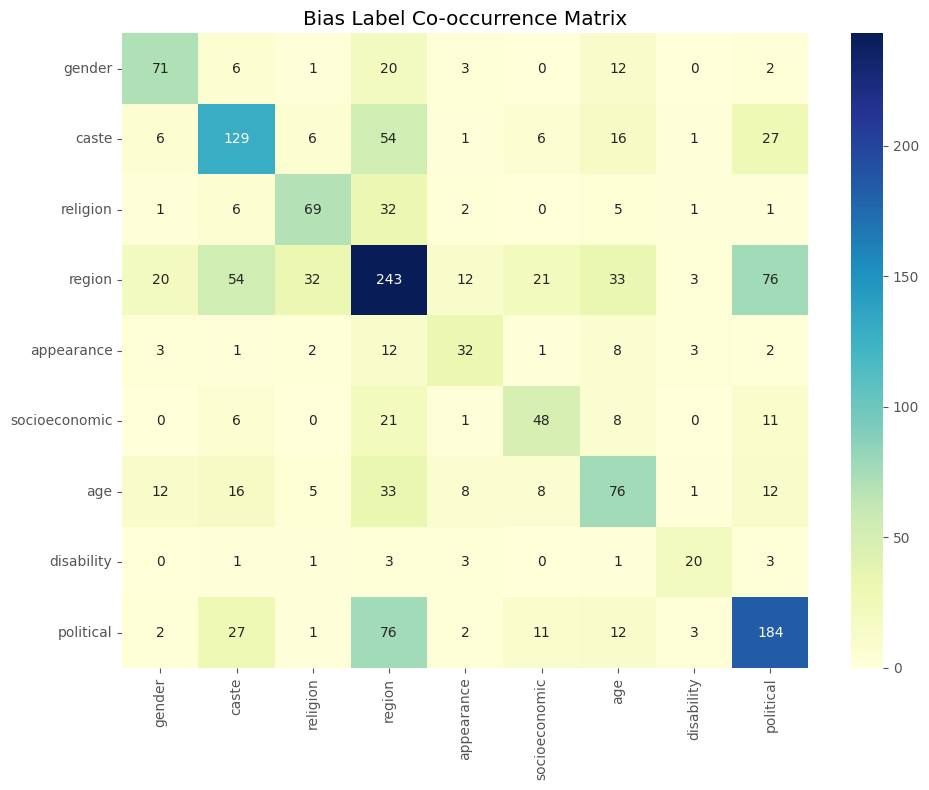

In [26]:
# Calculate co-occurrence matrix
co_matrix = df[categories].T.dot(df[categories])

plt.figure(figsize=(10, 8))
sns.heatmap(co_matrix, annot=True, cmap='YlGnBu', fmt='g')
plt.title('Bias Label Co-occurrence Matrix')
plt.tight_layout()
plt.show()

## Overview
The heatmap visualizes how frequently different bias labels appear together across a dataset. Diagonal values represent single-label occurrences, while off-diagonal values capture cross-label co-occurrences.

---

## Dominant Categories

- **Region** is the most prevalent bias label, with **243** self-occurrences — the highest diagonal value in the matrix, indicating it is the most commonly flagged standalone bias.
- **Caste (129)** and **Political (184)** follow as the next most dominant categories, suggesting these are heavily represented in the dataset.


---
## 🔗 Strongest Co-occurrences

| Pair | Count | Interpretation |
|------|-------|----------------|
| Region ↔ Political | 76 | The strongest cross-label link — regional identity frequently intersects with political bias |
| Region ↔ Caste | 54 | Regional content often carries caste-related undertones |
| Region ↔ Age | 33 | Age-related bias frequently surfaces alongside regional bias |
| Caste ↔ Political | 27 | Political discourse is closely tied to caste narratives |
| Region ↔ Religion | 32 | Religion and region co-occur significantly, reflecting socio-cultural overlap |



# Text Length analysis

In [28]:
# Calculate sentence length (in words)
df['word_count'] = df['sentence'].apply(lambda x: len(str(x).split()))

print(f"Average word count: {df['word_count'].mean():.2f}")
print(f"Max word count: {df['word_count'].max()}")
print(f"Min word count: {df['word_count'].min()}")


Average word count: 8.39
Max word count: 34
Min word count: 3
